<a href="https://colab.research.google.com/github/andres-merino/labs-comp-cuantica/blob/main/Algebra-lineal/Laboratorio2-ProdTensorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 22%; vertical-align: middle; padding-right: 10px;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/d/df/Logo_UNIR.png" width="250">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#3facc9" size="7">|</font><br>
            <font color="#3facc9" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#3facc9" size="5">
                <b>Maestria en Computacion Cuantica</b>
            </font></p>
            <p style="font-variant: small-caps;"><font color="#3facc9" size="4">
                Algebra Lineal en Computacion Cuantica - Laboratorio 2: Producto Tensorial y Esfera de Bloch
            </font></p>
            <p style="font-style: oblique;"><font color="#3facc9" size="3">
                Mayo 2026
            </font></p>
        </td>
    </tr>
</table>

---
## <font color='3facc9'> Paquetes </font>

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization.bloch import Bloch
from qiskit.circuit.library import XGate, YGate, ZGate, HGate
from IPython.display import display, Latex

---
## <font color='3facc9'> Definicion de matrices unitarias </font>

Las matrices unitarias de Pauli e identidad utilizadas en los ejercicios son:

$$
I = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}, \quad
X = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}, \quad
Y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}, \quad
Z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}
$$

In [23]:
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

for nombre, M in [("I", I), ("X", X), ("Y", Y), ("Z", Z)]:
    print(f"Matriz {nombre}:")
    display(sp.Matrix(M).applyfunc(sp.nsimplify))

Matriz I:


Matrix([
[1, 0],
[0, 1]])

Matriz X:


Matrix([
[0, 1],
[1, 0]])

Matriz Y:


Matrix([
[0, -I],
[I,  0]])

Matriz Z:


Matrix([
[1,  0],
[0, -1]])

Definimos una función para calcular las coordendas del vector de Bloch a partir de un estado cuántico dado. 

In [37]:
# Función para obtener coordenadas de Bloch
def bloch_coords(state):
    a, b = state.data
    x = 2 * np.real(np.conj(a) * b)
    y = 2 * np.imag(np.conj(b) * a)
    z = np.abs(a)**2 - np.abs(b)**2
    return [x, y, z]

---
## <font color='3facc9'> Ejercicio 1: Calculo del producto tensorial </font>

Determina el producto tensorial de las siguientes combinaciones de matrices unitarias

1. $X \otimes I \otimes Z \otimes I$
2. $I \otimes Y \otimes Z \otimes X$
3. $Z \otimes X \otimes I$

In [30]:
# Producto tensorial
T1 = np.kron(np.kron(np.kron(X, I), Z), I)  # X⊗I⊗Z⊗I
T2 = np.kron(np.kron(np.kron(I, Y), Z), X)  # I⊗Y⊗Z⊗X
T3 = np.kron(np.kron(Z, X), I)              # Z⊗X⊗I

for nombre, M, expr in [
    ("T1", T1, r"X \otimes I \otimes Z \otimes I"),
    ("T2", T2, r"I \otimes Y \otimes Z \otimes X"),
    ("T3", T3, r"Z \otimes X \otimes I"),
]:
    print(f"Dimension de {nombre}: {M.shape}")
    display(Latex(f"${expr} =$"))
    display(sp.Matrix(M).applyfunc(sp.nsimplify))
    print()

Dimension de T1: (16, 16)


<IPython.core.display.Latex object>

Matrix([
[0, 0,  0,  0, 0, 0,  0,  0, 1, 0,  0,  0, 0, 0,  0,  0],
[0, 0,  0,  0, 0, 0,  0,  0, 0, 1,  0,  0, 0, 0,  0,  0],
[0, 0,  0,  0, 0, 0,  0,  0, 0, 0, -1,  0, 0, 0,  0,  0],
[0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0, -1, 0, 0,  0,  0],
[0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0, 1, 0,  0,  0],
[0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0, 0, 1,  0,  0],
[0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0, 0, 0, -1,  0],
[0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0, -1],
[1, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0],
[0, 1,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0],
[0, 0, -1,  0, 0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0],
[0, 0,  0, -1, 0, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0],
[0, 0,  0,  0, 1, 0,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0],
[0, 0,  0,  0, 0, 1,  0,  0, 0, 0,  0,  0, 0, 0,  0,  0],
[0, 0,  0,  0, 0, 0, -1,  0, 0, 0,  0,  0, 0, 0,  0,  0],
[0, 0,  0,  0, 0, 0,  0, -1, 0, 0,  0,  0, 0, 0,  0,  0]])


Dimension de T2: (16, 16)


<IPython.core.display.Latex object>

Matrix([
[0, 0,  0,  0,  0, -I, 0, 0, 0, 0,  0,  0,  0,  0, 0, 0],
[0, 0,  0,  0, -I,  0, 0, 0, 0, 0,  0,  0,  0,  0, 0, 0],
[0, 0,  0,  0,  0,  0, 0, I, 0, 0,  0,  0,  0,  0, 0, 0],
[0, 0,  0,  0,  0,  0, I, 0, 0, 0,  0,  0,  0,  0, 0, 0],
[0, I,  0,  0,  0,  0, 0, 0, 0, 0,  0,  0,  0,  0, 0, 0],
[I, 0,  0,  0,  0,  0, 0, 0, 0, 0,  0,  0,  0,  0, 0, 0],
[0, 0,  0, -I,  0,  0, 0, 0, 0, 0,  0,  0,  0,  0, 0, 0],
[0, 0, -I,  0,  0,  0, 0, 0, 0, 0,  0,  0,  0,  0, 0, 0],
[0, 0,  0,  0,  0,  0, 0, 0, 0, 0,  0,  0,  0, -I, 0, 0],
[0, 0,  0,  0,  0,  0, 0, 0, 0, 0,  0,  0, -I,  0, 0, 0],
[0, 0,  0,  0,  0,  0, 0, 0, 0, 0,  0,  0,  0,  0, 0, I],
[0, 0,  0,  0,  0,  0, 0, 0, 0, 0,  0,  0,  0,  0, I, 0],
[0, 0,  0,  0,  0,  0, 0, 0, 0, I,  0,  0,  0,  0, 0, 0],
[0, 0,  0,  0,  0,  0, 0, 0, I, 0,  0,  0,  0,  0, 0, 0],
[0, 0,  0,  0,  0,  0, 0, 0, 0, 0,  0, -I,  0,  0, 0, 0],
[0, 0,  0,  0,  0,  0, 0, 0, 0, 0, -I,  0,  0,  0, 0, 0]])


Dimension de T3: (8, 8)


<IPython.core.display.Latex object>

Matrix([
[0, 0, 1, 0,  0,  0,  0,  0],
[0, 0, 0, 1,  0,  0,  0,  0],
[1, 0, 0, 0,  0,  0,  0,  0],
[0, 1, 0, 0,  0,  0,  0,  0],
[0, 0, 0, 0,  0,  0, -1,  0],
[0, 0, 0, 0,  0,  0,  0, -1],
[0, 0, 0, 0, -1,  0,  0,  0],
[0, 0, 0, 0,  0, -1,  0,  0]])

---
## <font color='3facc9'> Ejercicio 2: Aplicaciones del producto tensorial </font>

### Parte a)

Calcular:

$$
M = \frac{2}{3}(X \otimes Z \otimes I) + \frac{1}{4}(I \otimes Z \otimes X) - \frac{5}{6}(Y \otimes Y \otimes Z)
$$

In [31]:
# Calculamos cada termino como producto tensorial
term1 = np.kron(np.kron(X, Z), I)  # X⊗Z⊗I
term2 = np.kron(np.kron(I, Z), X)  # I⊗Z⊗X
term3 = np.kron(np.kron(Y, Y), Z)  # Y⊗Y⊗Z

# Realizamos la combinacion lineal
M = (2/3)*term1 + (1/4)*term2 - (5/6)*term3

print("Matriz M = (2/3)(X⊗Z⊗I) + (1/4)(I⊗Z⊗X) - (5/6)(Y⊗Y⊗Z):")
print(f"Dimension: {M.shape}")
# Visualizacion del resultado
display(sp.Matrix(M).applyfunc(lambda x: sp.nsimplify(x, rational=True)))

Matriz M = (2/3)(X⊗Z⊗I) + (1/4)(I⊗Z⊗X) - (5/6)(Y⊗Y⊗Z):
Dimension: (8, 8)


Matrix([
[  0,  1/4,    0,    0,  2/3,   0,  5/6,    0],
[1/4,    0,    0,    0,    0, 2/3,    0, -5/6],
[  0,    0,    0, -1/4, -5/6,   0, -2/3,    0],
[  0,    0, -1/4,    0,    0, 5/6,    0, -2/3],
[2/3,    0, -5/6,    0,    0, 1/4,    0,    0],
[  0,  2/3,    0,  5/6,  1/4,   0,    0,    0],
[5/6,    0, -2/3,    0,    0,   0,    0, -1/4],
[  0, -5/6,    0, -2/3,    0,   0, -1/4,    0]])

### Parte b)

Calcula
$$
\langle 101 | \, M \, | 010 \rangle,
$$
donde $M$ es la matriz de la parte anterior. 

In [ ]:
# Definimos los vectores de la base computacional de un qubit
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

# Estados de 3 qubits por producto tensorial
# |010>
ket010 = np.kron(np.kron(ket0, ket1), ket0)
# |101>
ket101 = np.kron(np.kron(ket1, ket0), ket1)

# Calculamos el resultado
resultado = ket101.conj().T @ M @ ket010

display(Latex(
    r"$\langle 101 | M | 010 \rangle = " + sp.latex(sp.nsimplify(resultado, rational=True)) + "$"
))

<IPython.core.display.Latex object>

---
## <font color='3facc9'> Ejercicio 3: Visualizacion en la esfera de Bloch </font>

Representa en una única esfera de Bloch los siguientes estados cuánticos:
$$
|0\rangle, \quad |1\rangle, \quad |+\rangle = \frac{|0\rangle+|1\rangle}{\sqrt{2}}, \quad
|-\rangle = \frac{|0\rangle-|1\rangle}{\sqrt{2}}, \quad
|i+\rangle = \frac{|0\rangle+i|1\rangle}{\sqrt{2}}, \quad
|i-\rangle = \frac{|0\rangle-i|1\rangle}{\sqrt{2}}.
$$

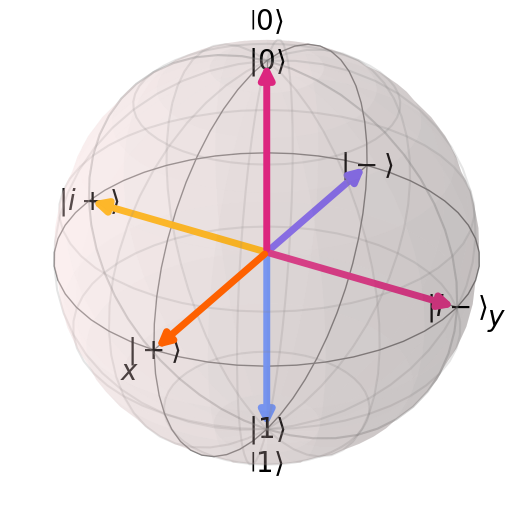

In [39]:
# Definicion de los seis estados como Statevector de Qiskit
estados = [
    (r"$|0\rangle$",   Statevector([1, 0])),
    (r"$|1\rangle$",   Statevector([0, 1])),
    (r"$|+\rangle$",   Statevector([1,  1]) / np.sqrt(2)),
    (r"$|-\rangle$",   Statevector([1, -1]) / np.sqrt(2)),
    (r"$|i+\rangle$",  Statevector([1,  1j]) / np.sqrt(2)),
    (r"$|i-\rangle$",  Statevector([1, -1j]) / np.sqrt(2)),
]

# Crear esfera de Bloch
bloch = Bloch()

# Agregar vectores y etiquetas
for etiqueta, estado in estados:
    coords = bloch_coords(estado)

    bloch.add_vectors(coords)
    bloch.add_annotation(coords, etiqueta)

# Mostrar
bloch.render()
plt.show()

---
## <font color='3facc9'> Ejercicio 4: Efecto de las puertas cuanticas en la esfera de Bloch </font>

 Para cada caso, visualiza en la esfera de Bloch el efecto de las siguientes puertas aplicadas a los estados $|0\rangle$ y $|1\rangle$:

$$
X = \begin{bmatrix}0&1\\1&0\end{bmatrix}, \quad
Y = \begin{bmatrix}0&-i\\i&0\end{bmatrix}, \quad
Z = \begin{bmatrix}1&0\\0&-1\end{bmatrix}, \quad
H = \frac{1}{\sqrt{2}}\begin{bmatrix}1&1\\1&-1\end{bmatrix}.
$$

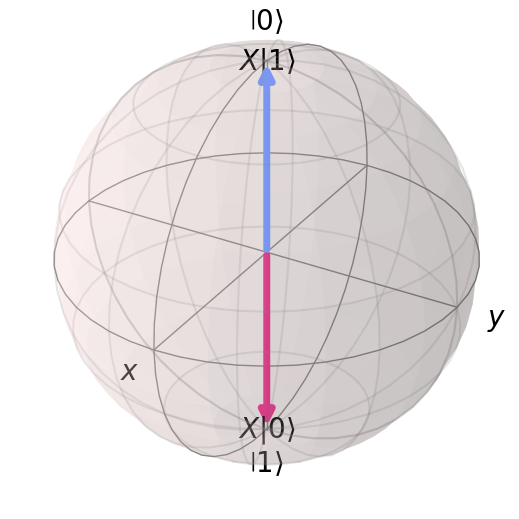

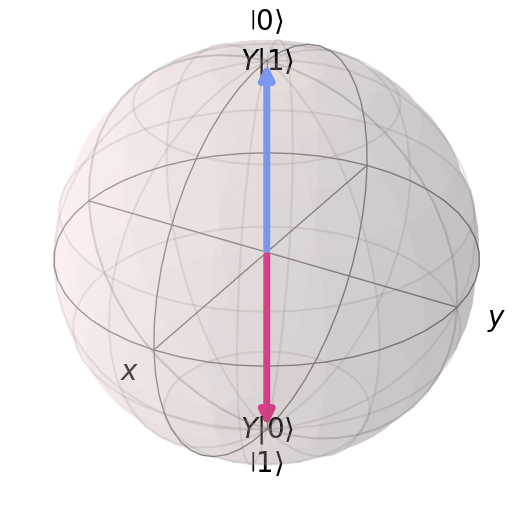

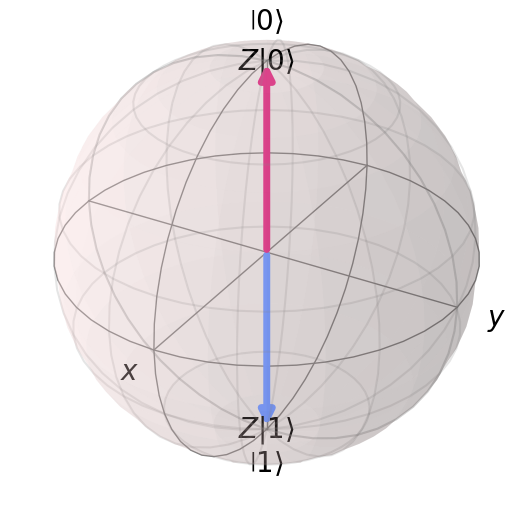

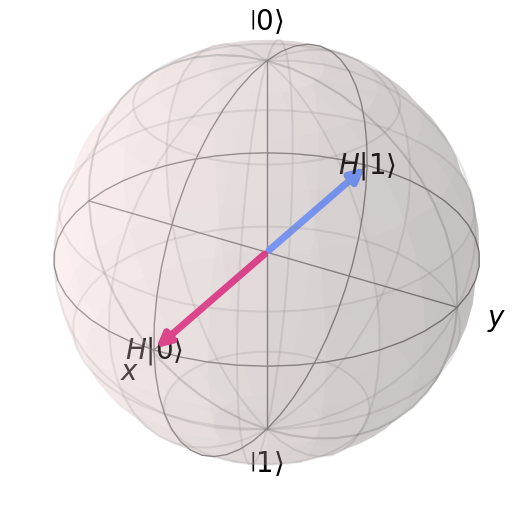

In [40]:
# Estados iniciales
estados_iniciales = [
    (r"$|0\rangle$", Statevector([1, 0])),
    (r"$|1\rangle$", Statevector([0, 1])),
]

# Puertas cuánticas
puertas = [
    ("X", Operator(XGate())),
    ("Y", Operator(YGate())),
    ("Z", Operator(ZGate())),
    ("H", Operator(HGate())),
]

# Visualización
for nombre_puerta, puerta in puertas:
    bloch = Bloch()
    bloch.title = f"Efecto de la puerta {nombre_puerta}"

    for etiqueta, estado in estados_iniciales:
        estado_final = estado.evolve(puerta)
        coords = bloch_coords(estado_final)

        bloch.add_vectors(coords)
        bloch.add_annotation(
            coords,
            rf"${nombre_puerta}{etiqueta[1:-1]}$"
        )

    bloch.render()
    plt.show()